In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import InfoGlobe
from InfoGlobe.metrics import fisher_rao_dis_matrix
from InfoGlobe.utils import get_knn


/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
adata = sc.read_h5ad('sim_data/adata/adata_1.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 6000 × 1100
    obs: 'cell_type'

In [5]:
P = adata.X
P = P / P.sum(axis=1, keepdims=True)
P_gd = P.T

<Axes: >

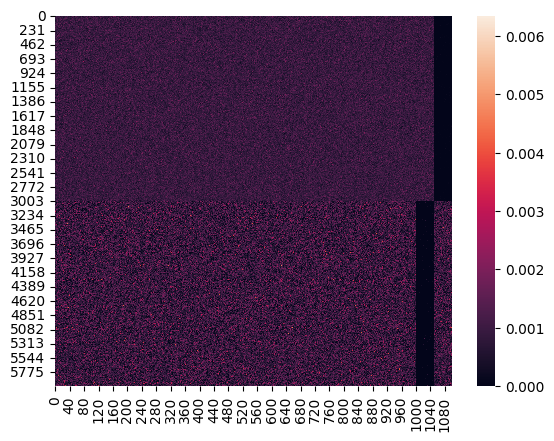

In [6]:
sns.heatmap(P)

In [7]:
n, m = P_gd.shape
k = 3

In [8]:
gb = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)

In [9]:
gb.fit(torch.Tensor(P_gd), max_iter=20000)

  0%|          | 0/20000 [00:00<?, ?it/s]/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 20000/20000 [01:30<00:00, 219.82it/s]


20000

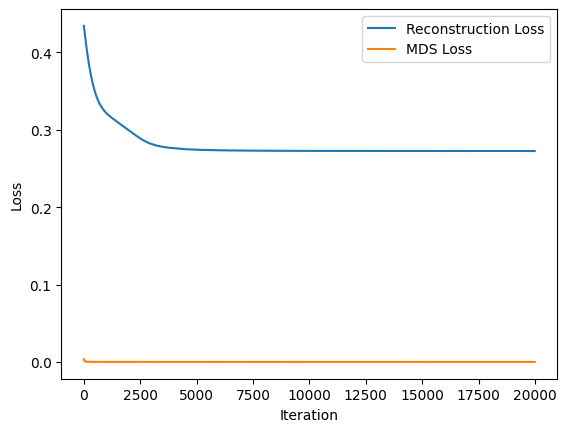

In [10]:
x = [i*10 for i in range(len(gb.loss1))]               

plt.plot(x, gb.loss1, label='Reconstruction Loss')        
plt.plot(x, gb.loss2, label='MDS Loss')                   

plt.xlabel("Iteration")
plt.ylabel("Loss")         
plt.legend()
plt.show()      

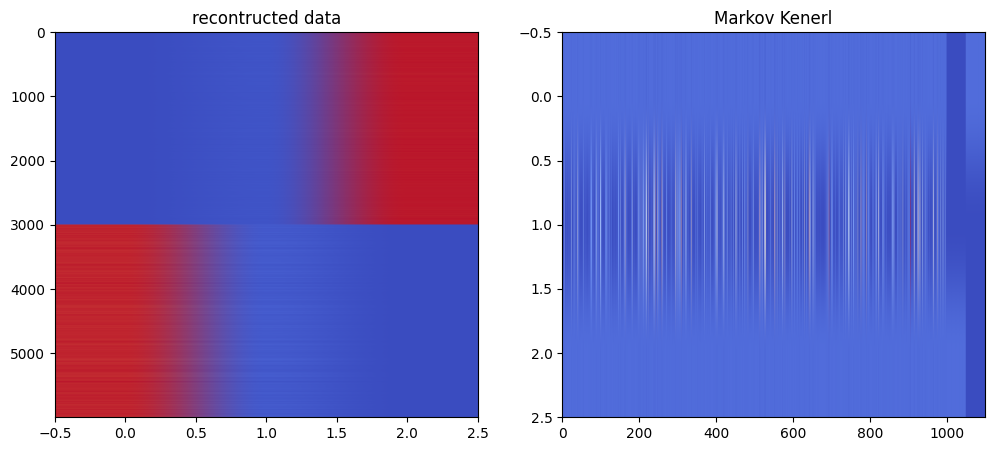

In [11]:
plt.figure(figsize=(12, 5))

# plt.subplot(1, 3, 1)
# plt.title("raw Data")
# plt.imshow(Q.T, aspect='auto', cmap='coolwarm')

plt.subplot(1, 2, 1)
plt.title("recontructed data")
plt.imshow(gb.Q.detach().cpu().numpy().T, aspect='auto', cmap='coolwarm')

plt.subplot(1, 2, 2)
plt.title("Markov Kenerl")
plt.imshow(gb.A.detach().cpu().numpy().T, aspect='auto', cmap='coolwarm')


plt.show()